In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

print("Tout fonctionne !")

Matplotlib is building the font cache; this may take a moment.


Tout fonctionne !


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('salesdaily.csv', sep=';')
print(df.shape)
print(df.head())

(2106, 13)
      datum  M01AB  M01AE  N02BA  N02BE  N05B  N05C   R03  R06  Year  Month  \
0  1/2/2014    0.0   3.67    3.4  32.40   7.0   0.0   0.0  2.0  2014      1   
1  1/3/2014    8.0   4.00    4.4  50.60  16.0   0.0  20.0  4.0  2014      1   
2  1/4/2014    2.0   1.00    6.5  61.85  10.0   0.0   9.0  1.0  2014      1   
3  1/5/2014    4.0   3.00    7.0  41.10   8.0   0.0   3.0  0.0  2014      1   
4  1/6/2014    5.0   1.00    4.5  21.70  16.0   2.0   6.0  2.0  2014      1   

   Hour Weekday Name  
0   248     Thursday  
1   276       Friday  
2   276     Saturday  
3   276       Sunday  
4   276       Monday  


In [14]:
# Nettoyage des données
df['datum'] = pd.to_datetime(df['datum'])
df = df.sort_values('datum')
df = df.set_index('datum')

print(df.shape)
df.head()

(2106, 12)


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
datum,,,,,,,,,,,,
2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [15]:
# Garder seulement les colonnes utiles
cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

df_monthly = df[cols].resample('ME').sum()

print(df_monthly.shape)
df_monthly.head()

(70, 8)


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
datum,,,,,,,,
2014-01-31,127.69,99.090,152.100,878.030,354.0,30.0,112.0,48.2
2014-02-28,133.32,126.050,177.000,1001.900,347.0,31.0,122.0,36.2
2014-03-31,137.44,92.950,147.655,779.275,232.0,20.0,112.0,85.4
2014-04-30,113.10,89.475,125.150,698.500,209.0,18.0,97.0,73.7
2014-05-31,101.79,119.933,132.100,628.780,270.0,23.0,107.0,123.7


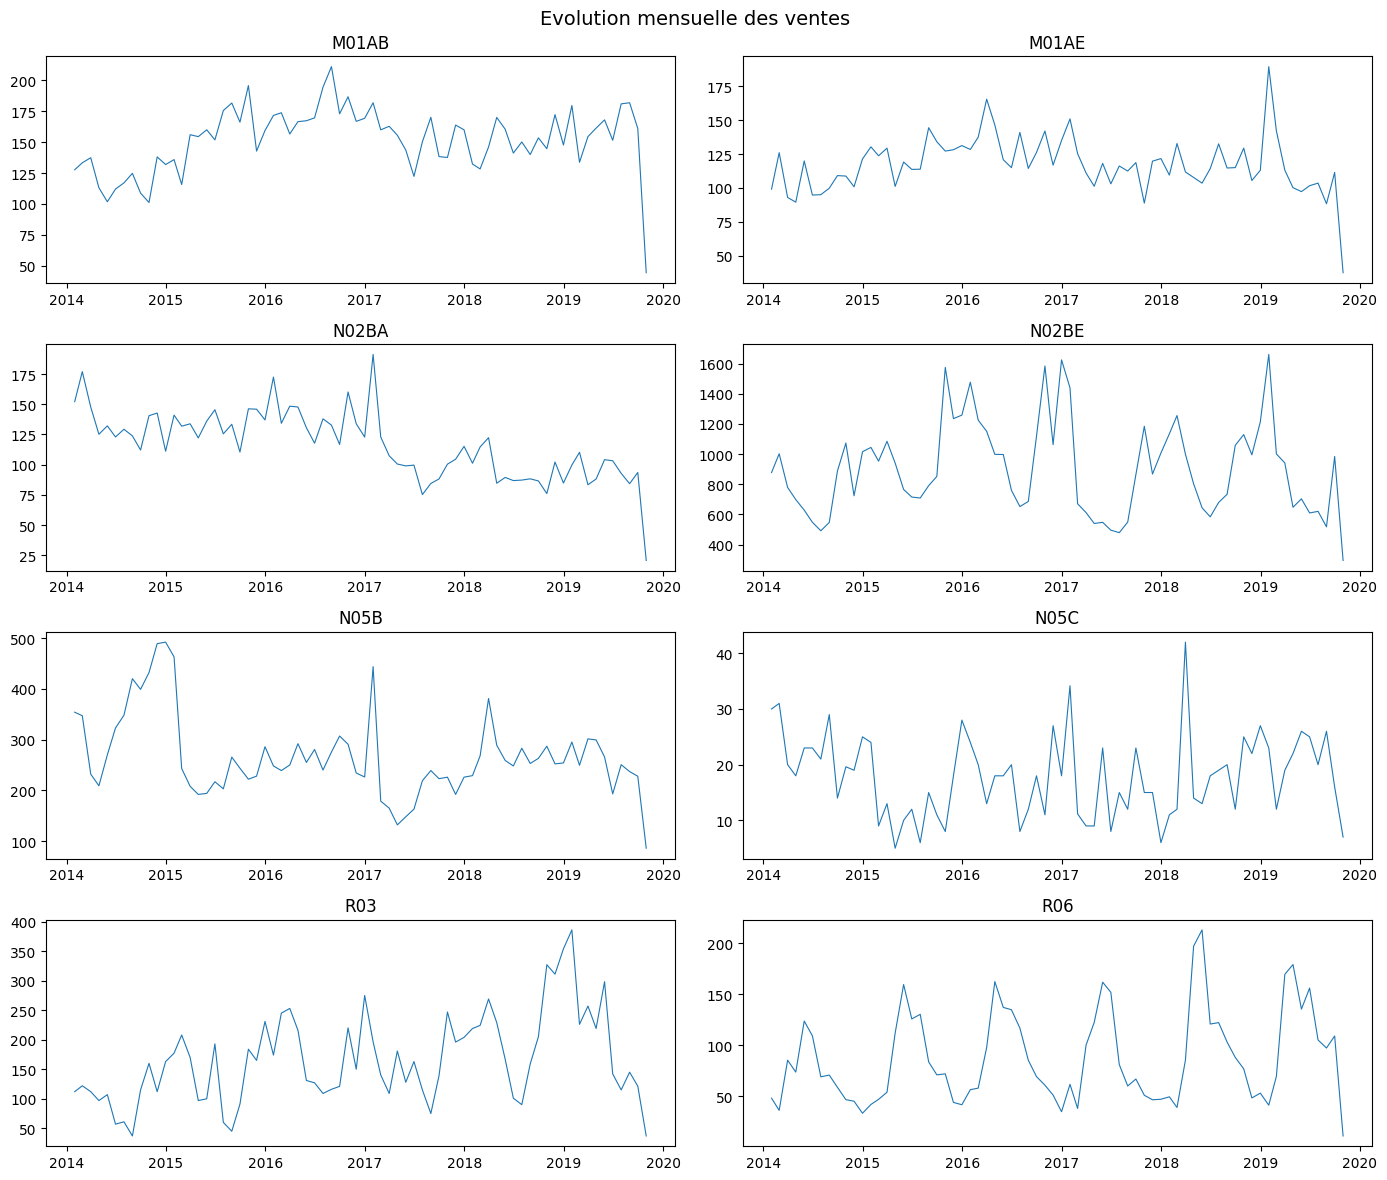

In [16]:
# Graphique 1 — Evolution des ventes par mois
cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].plot(df_monthly.index, df_monthly[col], linewidth=0.8)
    axes[i].set_title(col)

plt.suptitle('Evolution mensuelle des ventes', fontsize=14)
plt.tight_layout()
plt.show()

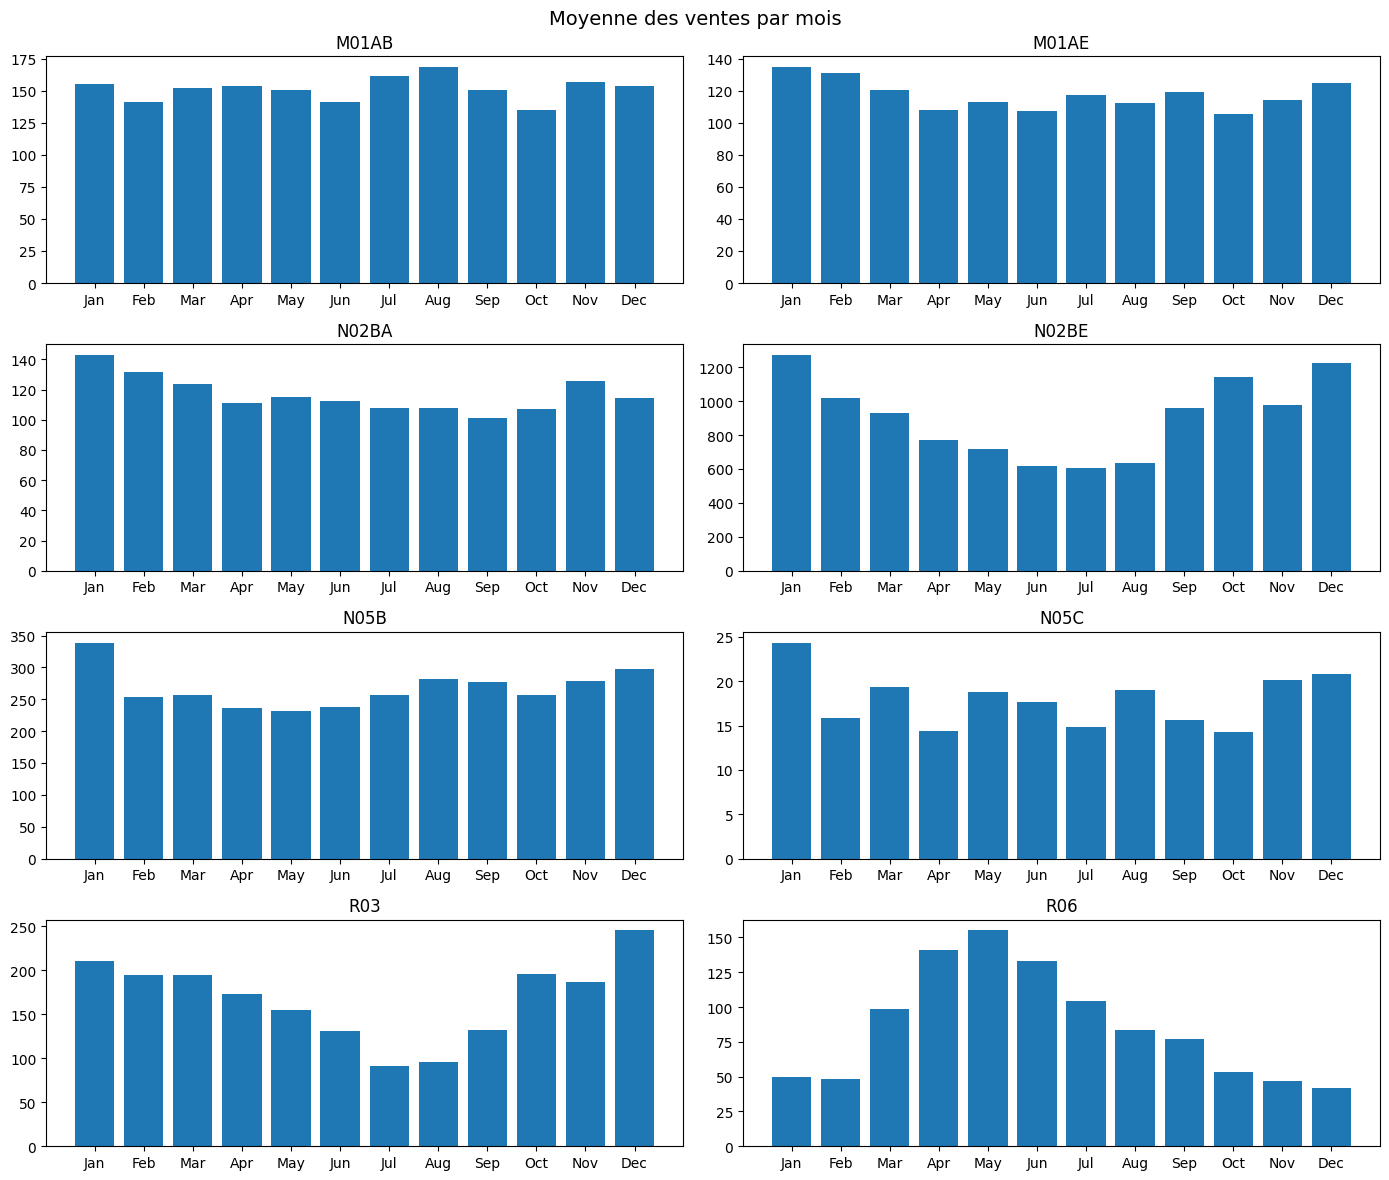

In [17]:
# Graphique 2 — Saisonnalité par mois
monthly_avg = df_monthly.copy()
monthly_avg['month'] = monthly_avg.index.month

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    avg = monthly_avg.groupby('month')[col].mean()
    axes[i].bar(range(1, 13), avg)
    axes[i].set_title(col)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                              'Jul','Aug','Sep','Oct','Nov','Dec'])

plt.suptitle('Moyenne des ventes par mois', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# Préparer les données pour le ML
target = 'N02BE'

df_feat = df_monthly.copy()
df_feat['month'] = df_feat.index.month
df_feat['year'] = df_feat.index.year
df_feat['lag1'] = df_feat[target].shift(1)
df_feat['lag2'] = df_feat[target].shift(2)
df_feat['lag3'] = df_feat[target].shift(3)
df_feat = df_feat.dropna()

print(df_feat.shape)
df_feat.head()

(67, 13)


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,month,year,lag1,lag2,lag3
datum,,,,,,,,,,,,,
2014-04-30,113.10,89.475,125.15,698.500,209.0,18.0,97.0,73.7,4,2014,779.275,1001.900,878.030
2014-05-31,101.79,119.933,132.10,628.780,270.0,23.0,107.0,123.7,5,2014,698.500,779.275,1001.900
2014-06-30,112.07,94.710,122.90,548.225,323.0,23.0,57.0,109.3,6,2014,628.780,698.500,779.275
2014-07-31,117.06,95.010,129.30,491.900,348.0,21.0,61.0,69.1,7,2014,548.225,628.780,698.500
2014-08-31,124.79,99.780,123.80,547.350,420.0,29.0,37.0,70.8,8,2014,491.900,548.225,628.780


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
models = {}

for target in cols:
    # Créer les features pour chaque médicament
    df_feat = df_monthly.copy()
    df_feat['month'] = df_feat.index.month
    df_feat['year'] = df_feat.index.year
    df_feat['lag1'] = df_feat[target].shift(1)
    df_feat['lag2'] = df_feat[target].shift(2)
    df_feat['lag3'] = df_feat[target].shift(3)
    df_feat = df_feat.dropna()

    # X et y
    X = df_feat[['month', 'year', 'lag1', 'lag2', 'lag3']]
    y = df_feat[target]

    # Entraînement
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Sauvegarder le modèle
    models[target] = {
        'model': model,
        'X_test': X_test,
        'y_test': y_test
    }
    print(f"✅ Modèle entraîné pour {target}")

print("\nTous les modèles sont prêts !")

✅ Modèle entraîné pour M01AB
✅ Modèle entraîné pour M01AE
✅ Modèle entraîné pour N02BA
✅ Modèle entraîné pour N02BE
✅ Modèle entraîné pour N05B
✅ Modèle entraîné pour N05C
✅ Modèle entraîné pour R03
✅ Modèle entraîné pour R06

Tous les modèles sont prêts !


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("=== Évaluation des modèles ===\n")

for target in cols:
    model = models[target]['model']
    X_test = models[target]['X_test']
    y_test = models[target]['y_test']
    
    # Prédictions
    y_pred = model.predict(X_test)
    
    # Calcul des erreurs
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"{target} → MAE: {mae:.2f} | RMSE: {rmse:.2f}")

=== Évaluation des modèles ===

M01AB → MAE: 23.91 | RMSE: 37.02
M01AE → MAE: 19.36 | RMSE: 29.49
N02BA → MAE: 14.73 | RMSE: 22.79
N02BE → MAE: 195.57 | RMSE: 300.34
N05B → MAE: 35.60 | RMSE: 55.69
N05C → MAE: 6.61 | RMSE: 7.34
R03 → MAE: 82.37 | RMSE: 101.36
R06 → MAE: 23.40 | RMSE: 40.13


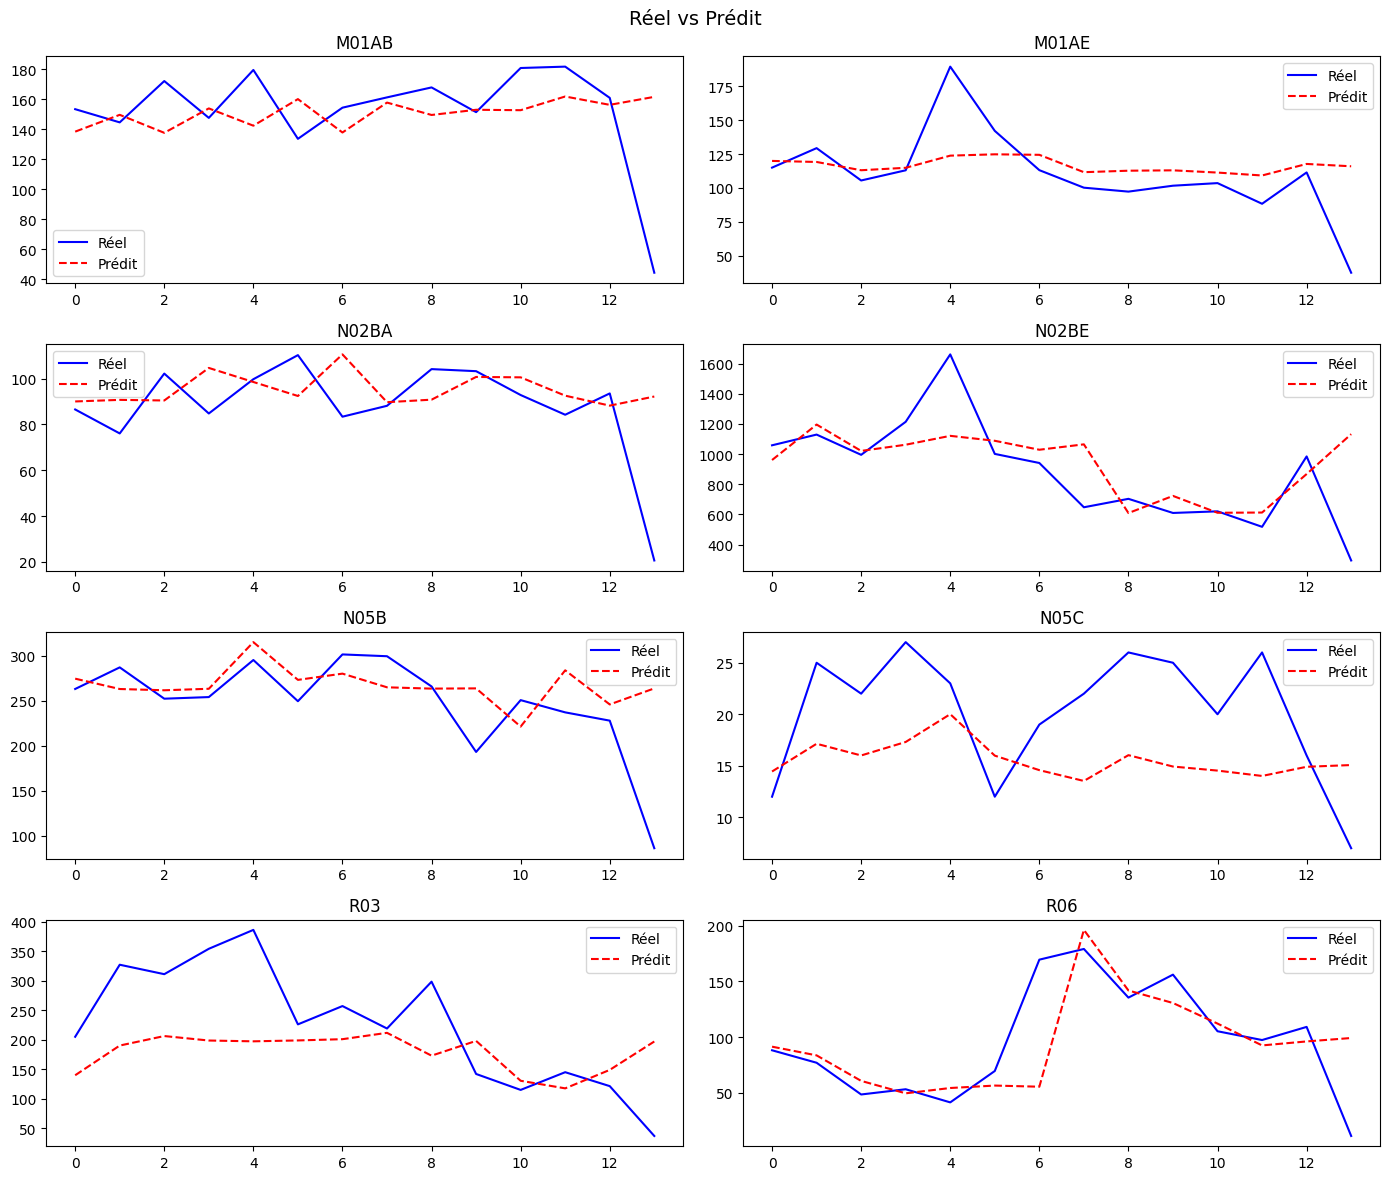

In [22]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, target in enumerate(cols):
    model = models[target]['model']
    X_test = models[target]['X_test']
    y_test = models[target]['y_test']
    
    y_pred = model.predict(X_test)
    
    axes[i].plot(y_test.values, label='Réel', color='blue')
    axes[i].plot(y_pred, label='Prédit', color='red', linestyle='--')
    axes[i].set_title(target)
    axes[i].legend()

plt.suptitle('Réel vs Prédit', fontsize=14)
plt.tight_layout()
plt.show()

In [23]:
# Prédire les ventes du prochain mois et recommander le stock
print("=== Recommandations de réapprovisionnement ===\n")

for target in cols:
    # Prendre les 3 derniers mois connus
    last_values = df_monthly[target].values[-3:]
    
    # Préparer les données pour la prédiction
    next_month = df_monthly.index[-1].month + 1
    next_year = df_monthly.index[-1].year
    if next_month > 12:
        next_month = 1
        next_year += 1
    
    X_next = pd.DataFrame([[next_month, next_year, 
                             last_values[-1], 
                             last_values[-2], 
                             last_values[-3]]], 
                           columns=['month', 'year', 'lag1', 'lag2', 'lag3'])
    
    prediction = models[target]['model'].predict(X_next)[0]
    seuil = prediction * 1.2  # stock minimum = prédiction + 20% de sécurité
    
    print(f"{target}:")
    print(f"   Ventes prévues : {prediction:.0f} unités")
    print(f"   Stock minimum recommandé : {seuil:.0f} unités")
    print()

=== Recommandations de réapprovisionnement ===

M01AB:
   Ventes prévues : 149 unités
   Stock minimum recommandé : 178 unités

M01AE:
   Ventes prévues : 106 unités
   Stock minimum recommandé : 128 unités

N02BA:
   Ventes prévues : 91 unités
   Stock minimum recommandé : 110 unités

N02BE:
   Ventes prévues : 887 unités
   Stock minimum recommandé : 1064 unités

N05B:
   Ventes prévues : 189 unités
   Stock minimum recommandé : 227 unités

N05C:
   Ventes prévues : 15 unités
   Stock minimum recommandé : 18 unités

R03:
   Ventes prévues : 160 unités
   Stock minimum recommandé : 192 unités

R06:
   Ventes prévues : 60 unités
   Stock minimum recommandé : 72 unités



In [24]:
import joblib
import os

# Créer un dossier pour les modèles
os.makedirs('models', exist_ok=True)

# Sauvegarder chaque modèle
for target in cols:
    joblib.dump(models[target]['model'], f'models/model_{target}.pkl')
    print(f"✅ Modèle {target} sauvegardé")

print("\nTous les modèles sont sauvegardés !")

✅ Modèle M01AB sauvegardé
✅ Modèle M01AE sauvegardé
✅ Modèle N02BA sauvegardé
✅ Modèle N02BE sauvegardé
✅ Modèle N05B sauvegardé
✅ Modèle N05C sauvegardé
✅ Modèle R03 sauvegardé
✅ Modèle R06 sauvegardé

Tous les modèles sont sauvegardés !
